In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.integrate import solve_ivp
import sympy

C:\Users\muliy\AppData\Local\Temp\ipykernel_5832\1650873866.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


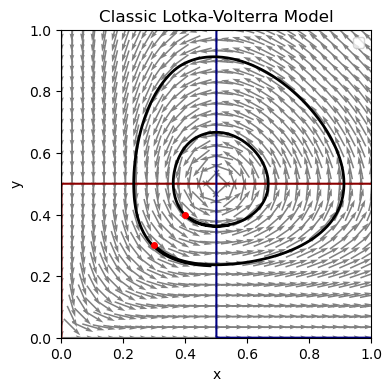

In [2]:
class PhasePlotter2D:
    def __init__(self, model, params=None):
        self.model = model
        self.params = params or ()
        self.solution = None

    def solve(self, init_cond, t_span=(0, 20), t_eval=None):
        self.solution = solve_ivp(
            lambda t, y: self.model(t, y, *self.params),
            t_span,
            init_cond,
            t_eval=t_eval
        )
        return self.solution
    
    def plot_solve(self, ax, init_conds, t_end=20, dt=0.01, color='black', lw=2):

        init_conds = np.atleast_2d(init_conds)
        t_eval = np.arange(0, t_end, dt)

        for init in init_conds:
            sol = solve_ivp(
                lambda t, y: self.model(t, y, *self.params),
                (0, t_end),
                init,
                t_eval=t_eval
            )
            ax.plot(sol.y[0], sol.y[1], color=color, lw=lw)
            ax.plot(sol.y[0][0], sol.y[1][0], 'ro', markersize=4)  # 起点标记

        return ax

    def plot_phase_diagram(self, x_range, y_range, density=1.5, ax=None):
        """绘制相图与向量场"""
        ax = ax or plt.gca()
        
        # 生成网格
        x = np.linspace(*x_range, int(20*density))
        y = np.linspace(*y_range, int(20*density))
        X, Y = np.meshgrid(x, y)
        
        # 计算向量场
        DX, DY = self.model(0, np.array([X, Y]), *self.params)
        norm = np.hypot(DX, DY) + 1e-8
        
        ax.quiver(X, Y, DX/norm, DY/norm, 
                 color='gray', 
                 scale=20/density,
                 width=0.005,
                 pivot='mid')
        
        if self.solution:
            ax.plot(self.solution.y[0], self.solution.y[1], 
                   'b-', lw=2, label='Solution')
            ax.plot(self.solution.y[0][0], self.solution.y[1][0], 'ro')
            
        ax.set(xlim=x_range, ylim=y_range,
              xlabel='x', ylabel='y')
        return ax

    def plot_nullclines(self, x_range, y_range, resolution=500, ax=None):
        ax = ax or plt.gca()
        x = np.linspace(*x_range, resolution)
        y = np.linspace(*y_range, resolution)
        X, Y = np.meshgrid(x, y)
        
        # 创建空的数组存储零增长曲线的结果
        DX = np.zeros_like(X)
        DY = np.zeros_like(Y)
        
        # 对每个点计算 dx/dt 和 dy/dt
        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                dxdt, dydt = self.model(0, [X[i, j], Y[i, j]], *self.params)
                DX[i, j], DY[i, j] = dxdt, dydt

        # 绘制 dx/dt = 0 和 dy/dt = 0 的曲线
        ax.contour(X, Y, DX, levels=[0], colors='darkred', linewidths=1.5)
        ax.contour(X, Y, DY, levels=[0], colors='navy', linewidths=1.5)
        
        # 添加图例
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], color='darkred', lw=1.5, label='dx/dt=0'),
            Line2D([0], [0], color='navy', lw=1.5, label='dy/dt=0')
        ]
        ax.legend(handles=legend_elements)
        return ax

# 使用示例
if __name__ == "__main__":
    # 定义微分方程函数
    def lv_2species(t, vars, r1, r2, a1, a2):
        x, y = vars
        return np.array([
            r1*x #- x**2 
            - a1 * x * y,
            r2*y #- y**2 
            - a2 * y * x
        ])
    
    # 设置参数

    params = (0.5,-0.5,1,-1) 
    
    # 初始化绘图器
    plotter = PhasePlotter2D(lv_2species, params=params)
    
    # 数值求解
    #plotter.solve([0.2, 0.8], t_span=(0, 50))
    
    # 创建画布
    fig, ax = plt.subplots(figsize=(4, 4))
    
    # 绘制图形
    plotter.plot_phase_diagram((0, 1), (0, 1), ax=ax)
    plotter.plot_nullclines((0, 1), (0, 1), ax=ax)

    ax = plotter.plot_solve(ax, [[0.3,0.3]], t_end=15, dt=0.01)
    ax = plotter.plot_solve(ax, [[0.4,0.4]], t_end=15, dt=0.01)
    
    ax.legend()
    plt.title("Classic Lotka-Volterra Model")
    plt.show()


C:\Users\muliy\AppData\Local\Temp\ipykernel_25184\3886572384.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


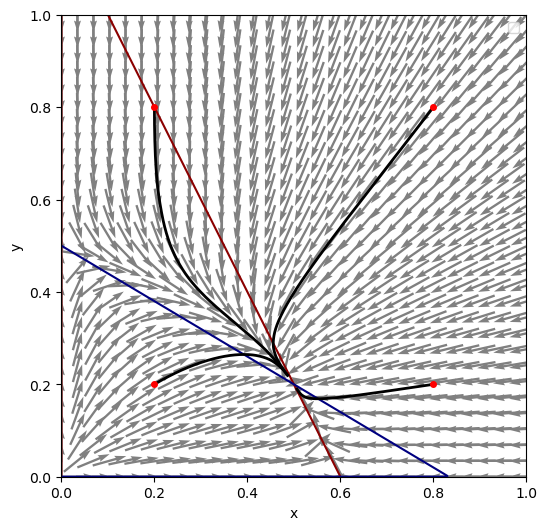

In [4]:
# 使用示例
if __name__ == "__main__":
    # 定义微分方程函数
    def glv_2species(t, vars, r1, r2, a1, a2):
        x, y = vars
        return np.array([
            r1*x - x**2 - a1 * x * y,
            r2*y - y**2 - a2 * y * x
        ])
    
    # 设置参数

    params = (0.6,0.5,0.5,0.6) 
    
    # 初始化绘图器
    plotter = PhasePlotter2D(glv_2species, params=params)
    
    # 数值求解
    #plotter.solve([0.2, 0.8], t_span=(0, 50))
    
    # 创建画布
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # 绘制图形
    plotter.plot_phase_diagram((0, 1), (0, 1), ax=ax)
    plotter.plot_nullclines((0, 1), (0, 1), ax=ax)

    plotter.plot_solve(ax, [[0.2,0.2]], t_end=15, dt=0.01)
    ax = plotter.plot_solve(ax, [[0.2,0.8]], t_end=15, dt=0.01)
    ax = plotter.plot_solve(ax, [[0.8,0.8]], t_end=15, dt=0.01)
    ax = plotter.plot_solve(ax, [[0.8,0.2]], t_end=15, dt=0.01)
    
    ax.legend()
    plt.show()


C:\Users\muliy\AppData\Local\Temp\ipykernel_25184\2502316671.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


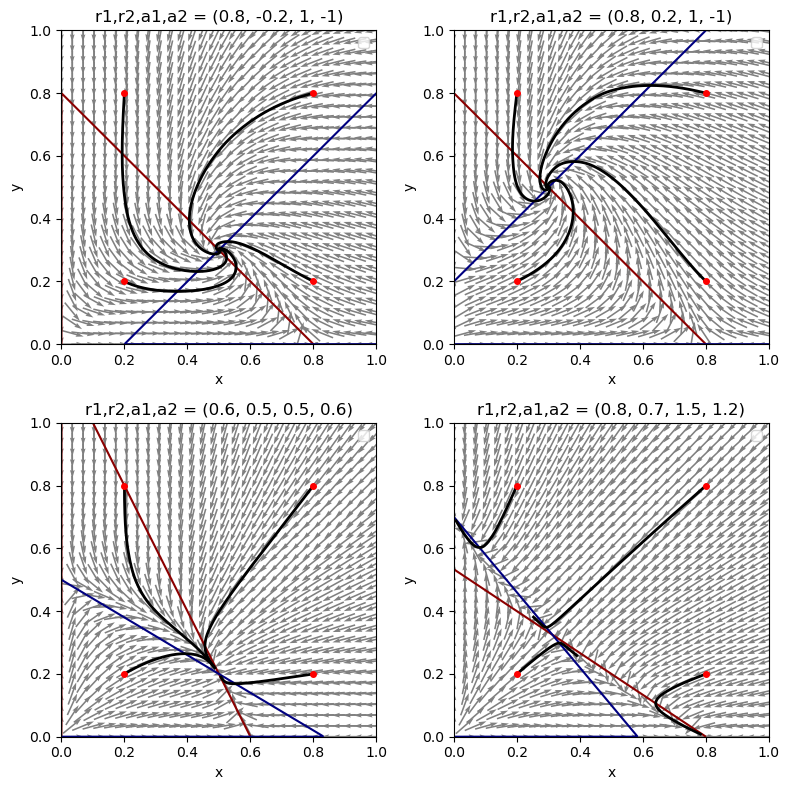

In [5]:
if __name__ == "__main__":

    params_a = [(0.8,-0.2,1,-1), (0.8,0.2,1,-1), (0.6,0.5,0.5,0.6), (0.8,0.7,1.5,1.2)]
    
    # 创建 2x2 子图
    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    axes = axes.flatten()

    
    # 遍历不同的 b 值
    for i in range(0,4):
        ax = axes[i]
        
        # 创建绘图器
        plotter = PhasePlotter2D(glv_2species, params=params_a[i])
        
        # 绘制相图和零流线
        plotter.plot_phase_diagram((0, 1), (0, 1), ax=ax)
        plotter.plot_nullclines((0, 1), (0, 1), ax=ax)
        
        # 绘制轨迹
        plotter.plot_solve(ax, [0.2,0.2], t_end=15, dt=0.01)

        plotter.plot_solve(ax, [0.2,0.8], t_end=15, dt=0.01)

        plotter.plot_solve(ax, [0.8,0.2], t_end=15, dt=0.01)

        plotter.plot_solve(ax, [0.8,0.8], t_end=15, dt=0.01)
        
        ax.set_title(f"r1,r2,a1,a2 = {params_a[i]}")
        ax.legend()
    
    plt.tight_layout()
    plt.show()

C:\Users\muliy\AppData\Local\Temp\ipykernel_25184\1000867476.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


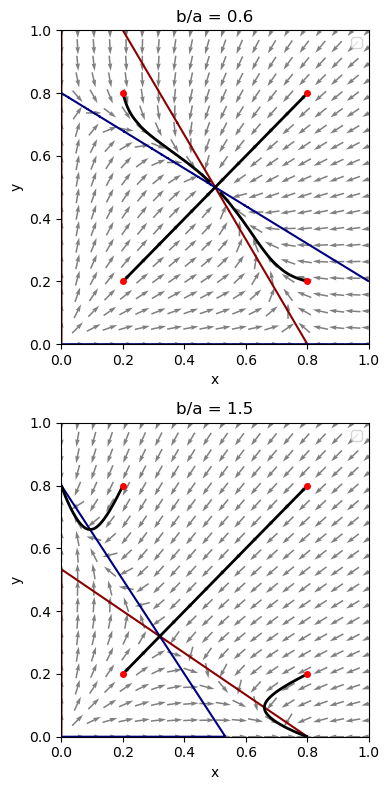

In [6]:
if __name__ == "__main__":

    params_a = [(0.8, 0.8, 0.6, 0.6), (0.8, 0.8, 1.5, 1.5)]
    
    # 创建 2x2 子图
    fig, axes = plt.subplots(2, 1, figsize=(4, 8))
    axes = axes.flatten()

    
    # 遍历不同的 b 值
    for i in range(0,2):
        ax = axes[i]
        
        # 创建绘图器
        plotter = PhasePlotter2D(glv_2species, params=params_a[i])
        
        # 绘制相图和零流线
        plotter.plot_phase_diagram((0, 1), (0, 1), ax=ax, density=1)
        plotter.plot_nullclines((0, 1), (0, 1), ax=ax)
        
        # 绘制轨迹
        plotter.plot_solve(ax, [0.2,0.2], t_end=15, dt=0.01)

        plotter.plot_solve(ax, [0.2,0.8], t_end=15, dt=0.01)

        plotter.plot_solve(ax, [0.8,0.2], t_end=15, dt=0.01)

        plotter.plot_solve(ax, [0.8,0.8], t_end=15, dt=0.01)
        
        ax.set_title(f"b/a = {params_a[i][3]}")
        ax.legend()
    
    plt.tight_layout()
    plt.show()

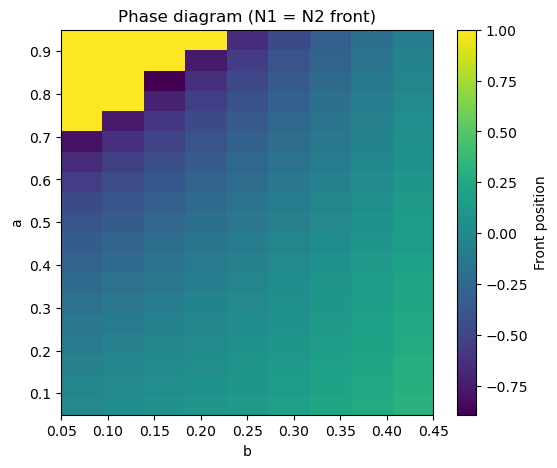

In [139]:
plt.figure(figsize=(6,5))

plt.imshow(front_map,
           origin='lower',
           extent=[b_list[0], b_list[-1],
                   a_list[0], a_list[-1]],
           aspect='auto')

plt.xlabel("b")
plt.ylabel("a")

plt.colorbar(label="Front position")

plt.title("Phase diagram (N1 = N2 front)")

plt.show()

C:\Users\muliy\AppData\Local\Temp\ipykernel_26932\1897325086.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


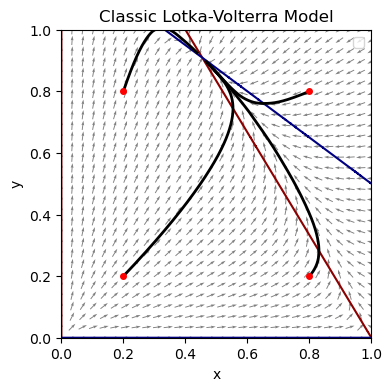

In [10]:
if __name__ == "__main__":
    # 定义微分方程函数
    def lv_2species(t, vars):
        x, y = vars
        return np.array([
            x - x**2 
            - 0.6 * x * y,
            y - 0.8*y**2 
            - 0.6* y * x
        ])
    
    
    # 初始化绘图器
    plotter = PhasePlotter2D(lv_2species)
    
    # 数值求解
    #plotter.solve([0.2, 0.8], t_span=(0, 50))
    
    # 创建画布
    fig, ax = plt.subplots(figsize=(4, 4))
    
    # 绘制图形
    plotter.plot_phase_diagram((0, 1), (0, 1), ax=ax)
    plotter.plot_nullclines((0, 1), (0, 1), ax=ax)

    plotter.plot_solve(ax, [0.2,0.2], t_end=15, dt=0.01)

    plotter.plot_solve(ax, [0.2,0.8], t_end=15, dt=0.01)

    plotter.plot_solve(ax, [0.8,0.2], t_end=15, dt=0.01)

    plotter.plot_solve(ax, [0.8,0.8], t_end=15, dt=0.01)
    
    ax.legend()
    plt.title("Classic Lotka-Volterra Model")
    plt.show()

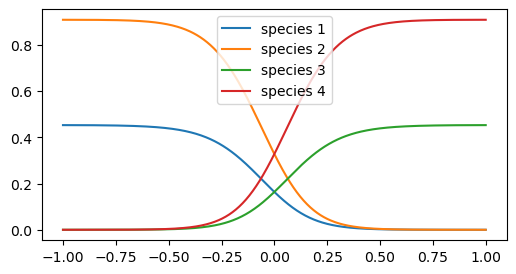

In [60]:
n = 4
D = [0.01, 0.01, 0.01, 0.01]
r = [1, 1.1, 1, 1.1]
A = np.array([[ 1.0,    0.6,    1.5,    1.5],
              [ 0.6,    0.8,    1.5,    1.5],
              [ 1.5,    1.5,    1.0,    0.6],
              [ 1.5,    1.5,    0.6,    0.8]])

model = ReactionDiffusion1D(D, r, A, xspan=(-1, 1), nx=500, dt=5e-4)

x = model.x
N0 = np.zeros((n, len(x)))
N0[0] = 1
N0[0][x>0] = 0
N0[1] = 0.9
N0[1][x>0] = 0
N0[2] = 1
N0[2][x<=0] = 0
N0[3] = 0.9
N0[3][x<=0] = 0

model.set_initial(N0)

records = model.run(steps=200000, record_interval=500)


fig, ax = plt.subplots(figsize=(6, 3))

plt.plot(x, records[-1][0], label='species 1')
plt.plot(x, records[-1][1], label='species 2')
plt.plot(x, records[-1][2], label='species 3')
plt.plot(x, records[-1][3], label='species 4')
plt.legend()
plt.show()

In [61]:
N = np.array(records[-1])   # shape = (n_species, n_x)

# ----------------------------
# 1. 计算 p_i = N_i / sum_i N_i
# ----------------------------

sum_N = np.sum(N, axis=0)   # 对每个 x，把所有 i 的 N_i 相加，shape = (n_x,)

# 避免除零
sum_N_safe = np.where(sum_N == 0, 1, sum_N)

p = N / sum_N_safe          # shape = (n_species, n_x)

# ----------------------------
# 2. 计算熵分布 S(x) = -sum_i p_i ln p_i
# ----------------------------

# 避免 log(0)
p_safe = np.where(p > 0, p, 1)

entropy_x = -np.sum(p * np.log(p_safe), axis=0)

# entropy_x 的 shape = (n_x,)
# 表示每个 x 点上的熵
print(entropy_x)

[0.63651705 0.63651773 0.63651908 0.63652111 0.63652383 0.63652723
 0.63653132 0.63653611 0.6365416  0.6365478  0.63655473 0.63656239
 0.63657079 0.63657995 0.63658987 0.63660058 0.63661209 0.63662442
 0.63663759 0.63665161 0.63666651 0.63668232 0.63669905 0.63671672
 0.63673538 0.63675505 0.63677575 0.63679752 0.63682039 0.6368444
 0.63686959 0.63689599 0.63692365 0.63695261 0.63698291 0.6370146
 0.63704772 0.63708234 0.6371185  0.63715626 0.63719568 0.63723682
 0.63727973 0.6373245  0.63737118 0.63741984 0.63747057 0.63752343
 0.63757851 0.63763589 0.63769566 0.63775791 0.63782273 0.63789022
 0.63796047 0.6380336  0.63810972 0.63818893 0.63827135 0.63835711
 0.63844633 0.63853914 0.63863568 0.63873609 0.63884051 0.6389491
 0.63906201 0.6391794  0.63930145 0.63942833 0.63956022 0.63969731
 0.63983979 0.63998787 0.64014175 0.64030165 0.64046779 0.64064041
 0.64081975 0.64100605 0.64119958 0.6414006  0.64160938 0.64182622
 0.64205141 0.64228525 0.64252807 0.64278019 0.64304196 0.6433137

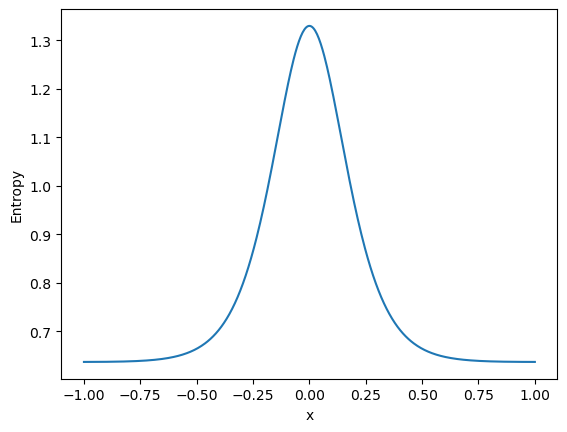

In [ ]:
plt.plot(x, entropy_x)
plt.xlabel('x')
plt.ylabel('Entropy')
plt.show()

In [63]:
# 对每个 i，计算 N_i(x) 在 x 上的积分
integrals = np.trapz(N, x=x, axis=1)

# integrals 的 shape = (n_species,)
# integrals[i] 就是第 i 个 N_i 的积分
print(integrals)

sum_IN = np.sum(integrals, axis=0) 

ip = integrals / sum_IN         # shape = (n_species, n_x)

gamma_div = -np.sum(ip * np.log(ip), axis=0)

# entropy_x 的 shape = (n_x,)
# 表示每个 x 点上的熵
print(gamma_div)

[0.41919553 0.84507222 0.41919553 0.84507222]
1.3284333580705394


In [64]:
alpha_div_avg = np.trapz(entropy_x, x=x)
print(alpha_div_avg)

1.5726692920853216


In [66]:
beta_div = gamma_div/alpha_div_avg
print(beta_div)

0.8446997501356873


In [79]:
import numpy as np
from scipy.optimize import curve_fit
N = np.array(records[-1])

# =========================
# logistic (supports reverse automatically)
# =========================
def logistic(x, L, k, x0, b):
    return L / (1 + np.exp(-k * (x - x0))) + b


# =========================
# Shannon entropy
# =========================
def shannon(p):
    p = p[p > 0]
    return -np.sum(p * np.log(p))


# =========================
# sampling (CORRECT)
# =========================
def sample_data(N, n):
    idx = np.linspace(0, N.shape[1] - 1, n, dtype=int)
    return N[:, idx], idx


# =========================
# correct discrete diversity
# =========================
def diversity_discrete_correct(N_sample, x_sample):
    S, m = N_sample.shape
    Hx = []

    for j in range(m):
        col = N_sample[:, j]
        total = np.sum(col)

        if total <= 0:
            Hx.append(0)
            continue

        p = col / total
        Hx.append(shannon(p))

    Hx = np.array(Hx)

    # ✔ 正确均值：用积分归一化
    H_mean = np.trapz(Hx, x_sample) / (x_sample[-1] - x_sample[0])
    H_int = np.trapz(Hx, x_sample)

    return H_mean, H_int, Hx


# =========================
# global diversity
# =========================
def diversity_global(N):
    A = np.sum(N, axis=1)
    if np.sum(A) == 0:
        return 0
    p = A / np.sum(A)
    return shannon(p)


# =========================
# logistic fit (USES SAMPLE ONLY)
# =========================
def fit_all_species(x, N_sample):
    S, n = N_sample.shape
    params_list = []

    for i in range(S):
        y = N_sample[i]

        if np.all(y == 0):
            params_list.append(None)
            continue

        dy = np.gradient(y)
        x0_guess = x[np.argmax(np.abs(dy))]

        # ✔ detect direction
        k_guess = 1.0 if np.mean(dy) > 0 else -1.0

        p0 = [
            np.max(y) - np.min(y),
            k_guess,
            x0_guess,
            np.min(y)
        ]

        try:
            params, _ = curve_fit(
                logistic,
                x, y,
                p0=p0,
                bounds=(
                    [0, -10, x.min(), -np.inf],
                    [np.inf, 10, x.max(), np.inf]
                ),
                maxfev=20000
            )
        except RuntimeError:
            params = None

        params_list.append(params)

    return params_list


# =========================
# evaluate fitted curves
# =========================
def eval_fit(x, params_list):
    S = len(params_list)
    F = np.zeros((S, len(x)))

    for i, p in enumerate(params_list):
        if p is not None:
            F[i] = logistic(x, *p)

    return F


# =========================
# continuous diversity
# =========================
def diversity_continuous(F, x):
    S, n = F.shape
    Hx = []

    for j in range(n):
        col = F[:, j]
        total = np.sum(col)

        if total <= 0:
            Hx.append(0)
            continue

        p = col / total
        Hx.append(shannon(p))

    Hx = np.array(Hx)

    H_mean = np.trapz(Hx, x) / (x[-1] - x[0])
    H_int = np.trapz(Hx, x)

    return H_mean, H_int, Hx


# =========================
# FULL PIPELINE (FIXED)
# =========================
def analyze(N, x, n):

    # ===== 1. sampling =====
    N_sample, idx = sample_data(N, n)
    x_sample = x[idx]

    # ===== 2. discrete diversity (FIXED) =====
    samp_mean, samp_int, Hx_sample = diversity_discrete_correct(N_sample, x_sample)
    samp_global = diversity_global(N_sample)

    # ===== 3. logistic fit (USES SAMPLE ONLY) =====
    params_list = fit_all_species(x_sample, N_sample)

    # ===== 4. continuous diversity =====
    F = eval_fit(x_sample, params_list)
    fit_mean, fit_int, Hx_fit = diversity_continuous(F, x_sample)
    fit_global = diversity_global(F)

    return {
        "sample_mean_div": samp_mean,
        "sample_integral_div": samp_int,
        "sample_global_div": samp_global,

        "fit_mean_div": fit_mean,
        "fit_integral_div": fit_int,
        "fit_global_div": fit_global,

        "Hx_sample": Hx_sample,
        "Hx_fit": Hx_fit,

        "sample_idx": idx,
        "params": params_list
    }


# =========================
# RUN
# =========================
result = analyze(N, x, 10)

print("=== SAMPLE (corrected) ===")
print("mean H:", result["sample_mean_div"])
print("integral H:", result["sample_integral_div"])
print("global H:", result["sample_global_div"])

print("\n=== FITTED ===")
print("mean H:", result["fit_mean_div"])
print("integral H:", result["fit_integral_div"])
print("global H:", result["fit_global_div"])

=== SAMPLE (corrected) ===
mean H: 1.1808205534222376
integral H: 2.361641106844475
global H: 1.6346156252377273

=== FITTED ===
mean H: 1.1813869722720334
integral H: 2.3627739445440668
global H: 1.634615625238277


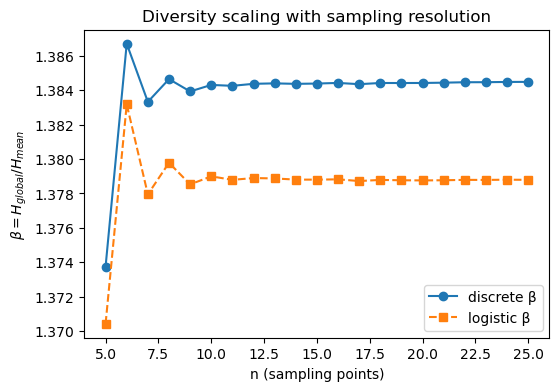

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ===== reuse your logistic =====
def logistic(x, L, k, x0, b):
    return L / (1 + np.exp(-k * (x - x0)) + 1e-12)

# ===== entropy =====
def shannon(p):
    p = p[p > 0]
    return -np.sum(p * np.log(p))

# =========================
# sampling
# =========================
def sample(N, n):
    idx = np.linspace(0, N.shape[1]-1, n, dtype=int)
    return N[:, idx], idx

# =========================
# diversity (DISCRETE)
# =========================
def diversity_discrete(Ns, x_s):
    S, m = Ns.shape
    Hx = []

    for j in range(m):
        col = Ns[:, j]
        if np.sum(col) == 0:
            Hx.append(0)
            continue
        p = col / np.sum(col)
        Hx.append(shannon(p))

    Hx = np.array(Hx)

    H_mean = np.trapz(Hx, x_s) / (x_s[-1] - x_s[0])
    H_global = shannon(np.sum(Ns, axis=1) / np.sum(Ns))

    return H_mean, H_global


# =========================
# fit logistic (SAME AS BEFORE)
# =========================
def fit_all_species(x_s, Ns):
    S = Ns.shape[0]
    params = []

    for i in range(S):
        y = Ns[i]

        if np.all(y == 0):
            params.append(None)
            continue

        dy = np.gradient(y)
        x0_guess = x_s[np.argmax(np.abs(dy))]
        k_guess = 1 if np.mean(dy) > 0 else -1

        p0 = [np.max(y)-np.min(y), k_guess, x0_guess, np.min(y)]

        try:
            p, _ = curve_fit(
                logistic, x_s, y,
                p0=p0,
                bounds=([0,-10,x_s.min(),-np.inf],
                        [np.inf,10,x_s.max(),np.inf]),
                maxfev=10000
            )
        except:
            p = None

        params.append(p)

    return params


# =========================
# continuous diversity (from fit)
# =========================
def diversity_continuous(F, x_s):
    S, m = F.shape
    Hx = []

    for j in range(m):
        col = F[:, j]
        if np.sum(col) == 0:
            Hx.append(0)
            continue
        p = col / np.sum(col)
        Hx.append(shannon(p))

    Hx = np.array(Hx)

    H_mean = np.trapz(Hx, x_s) / (x_s[-1] - x_s[0])
    H_global = shannon(np.sum(F, axis=1) / np.sum(F))

    return H_mean, H_global


# =========================
# evaluate fit
# =========================
def eval_fit(x_s, params):
    S = len(params)
    F = np.zeros((S, len(x_s)))

    for i, p in enumerate(params):
        if p is not None:
            F[i] = logistic(x_s, *p)

    return F


# =========================
# MAIN SWEEP
# =========================
n_list = np.arange(5, 26)

beta_discrete = []
beta_continuous = []

for n in n_list:

    Ns, idx = sample(N, n)
    x_s = x[idx]

    # ---- discrete ----
    Hm_d, Hg_d = diversity_discrete(Ns, x_s)
    beta_d = Hg_d / (Hm_d + 1e-12)
    beta_discrete.append(beta_d)

    # ---- fit ----
    params = fit_all_species(x_s, Ns)
    F = eval_fit(x_s, params)

    # ---- continuous ----
    Hm_c, Hg_c = diversity_continuous(F, x_s)
    beta_c = Hg_c / (Hm_c + 1e-12)
    beta_continuous.append(beta_c)


# =========================
# PLOT
# =========================
plt.figure(figsize=(6,4))

plt.plot(n_list, beta_discrete, 'o-', label='discrete β')
plt.plot(n_list, beta_continuous, 's--', label='logistic β')

plt.xlabel('n (sampling points)')
plt.ylabel(r'$\beta = H_{global}/H_{mean}$')
plt.legend()
plt.title('Diversity scaling with sampling resolution')

plt.show()

In [85]:
import numpy as np

def shannon(p):
    p = p[p > 0]
    return -np.sum(p * np.log(p))


# =========================
# TRUE DISCRETE FIELD
# =========================
def true_entropy(N, x):
    S, nx = N.shape

    Hx = []

    for j in range(nx):
        col = N[:, j]
        total = np.sum(col)

        if total == 0:
            Hx.append(0)
            continue

        p = col / total
        Hx.append(shannon(p))

    Hx = np.array(Hx)

    H_mean = np.trapz(Hx, x) / (x[-1] - x[0])
    H_global = shannon(np.sum(N, axis=1) / np.sum(N))

    return H_mean, H_global, Hx

H_true_mean, H_true_global, H_true_x = true_entropy(N, x)
beta=H_true_global/H_true_mean
beta


1.3846462899006424

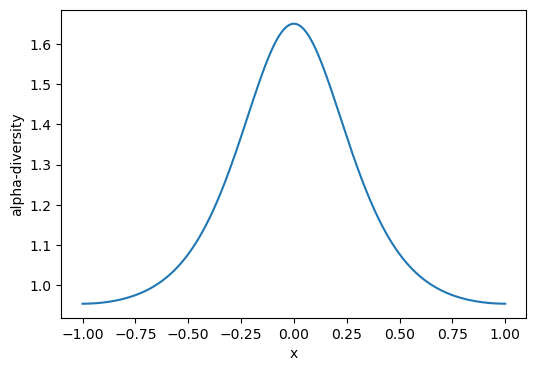

In [89]:
plt.figure(figsize=(6,4))
plt.plot(x, H_true_x)
plt.xlabel('x')
plt.ylabel('alpha-diversity')

plt.show()

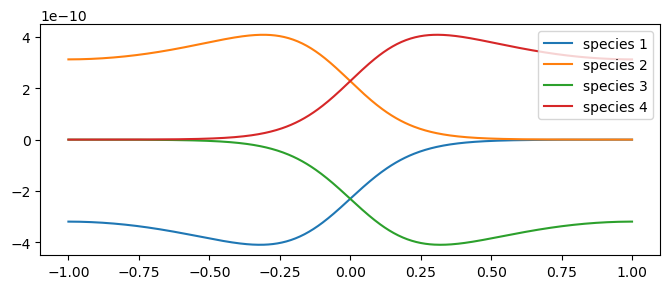

In [53]:
fig, ax = plt.subplots(figsize=(8, 3))

plt.plot(x, records[-1][0]-records[398][0], label='species 1')
plt.plot(x, records[-1][1]-records[398][1], label='species 2')
plt.plot(x, records[-1][2]-records[398][2], label='species 3')
plt.plot(x, records[-1][3]-records[398][3], label='species 4')
plt.legend()
plt.show()

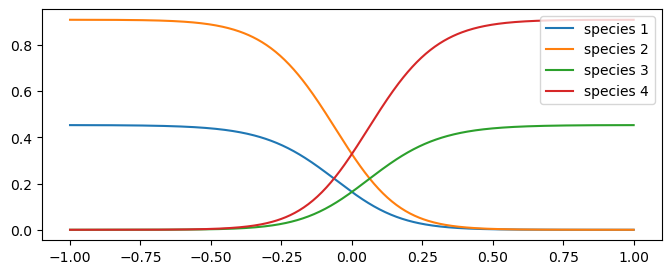

In [25]:
fig, ax = plt.subplots(figsize=(8, 3))

plt.plot(x, records[-1][0], label='species 1')
plt.plot(x, records[-1][1], label='species 2')
plt.plot(x, records[-1][2], label='species 3')
plt.plot(x, records[-1][3], label='species 4')
plt.legend(loc='upper right')
plt.show()

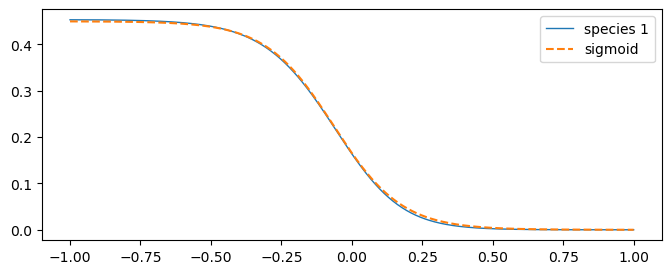

In [59]:
fig, ax = plt.subplots(figsize=(8, 3))

y = 0.45/(1+np.exp(8.3*x+0.54))

plt.plot(x, records[-1][0], '-', linewidth=1, label='species 1')
plt.plot(x, y, '--', label='sigmoid')
plt.legend(loc='upper right')
plt.show()

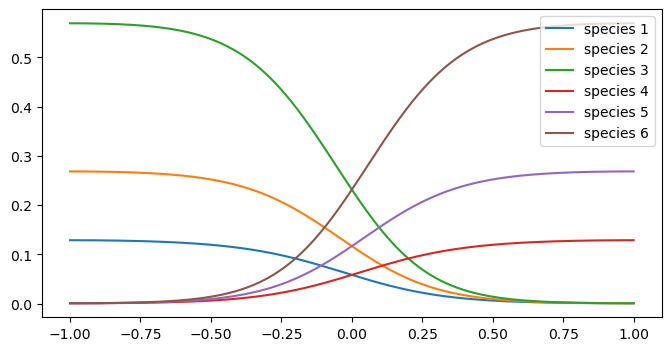

In [74]:
n = 6
D = [0.015, 0.012, 0.01, 0.015, 0.012, 0.01]
r = [1.1, 1.1, 1.1, 1.1, 1.1, 1.1]
A = np.array([[ 1.0,    1.05,    1.05,    1.5,    1.5,    1.5],
              [ 1.05,    1.0,    1.05,    1.5,    1.5,    1.5],
              [ 1.05,    1.05,    1.0,    1.5,    1.5,    1.5],
              [ 1.5,    1.5,    1.5,    1.0,    1.05,    1.05],
              [ 1.5,    1.5,    1.5,    1.05,    1.0,    1.05],
              [ 1.5,    1.5,    1.5,    1.05,    1.05,    1.0],])

model = ReactionDiffusion1D(D, r, A, xspan=(-1, 1), nx=500, dt=5e-4)

x = model.x
N0 = np.zeros((n, len(x)))
N0[0] = 1
N0[0][x>0] = 0
N0[1] = 1
N0[1][x>0] = 0
N0[2] = 1
N0[2][x>0] = 0
N0[3] = 1
N0[3][x<=0] = 0
N0[4] = 1
N0[4][x<=0] = 0
N0[5] = 1
N0[5][x<=0] = 0

model.set_initial(N0)

records = model.run(steps=200000, record_interval=500)


fig, ax = plt.subplots(figsize=(8, 4))

plt.plot(x, records[-1][0], label='species 1')
plt.plot(x, records[-1][1], label='species 2')
plt.plot(x, records[-1][2], label='species 3')
plt.plot(x, records[-1][3], label='species 4')
plt.plot(x, records[-1][4], label='species 5')
plt.plot(x, records[-1][5], label='species 6')
plt.legend(loc='upper right')
plt.show()

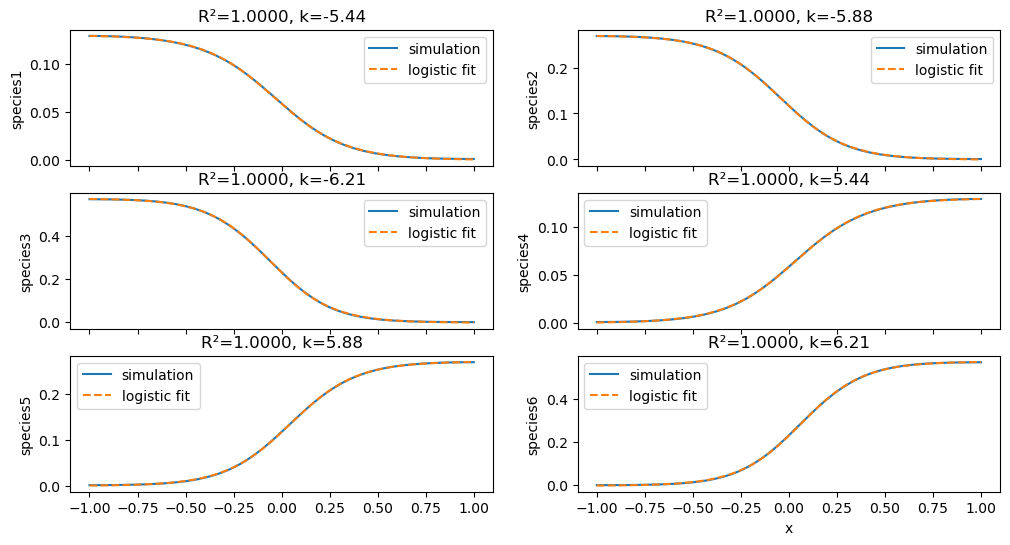

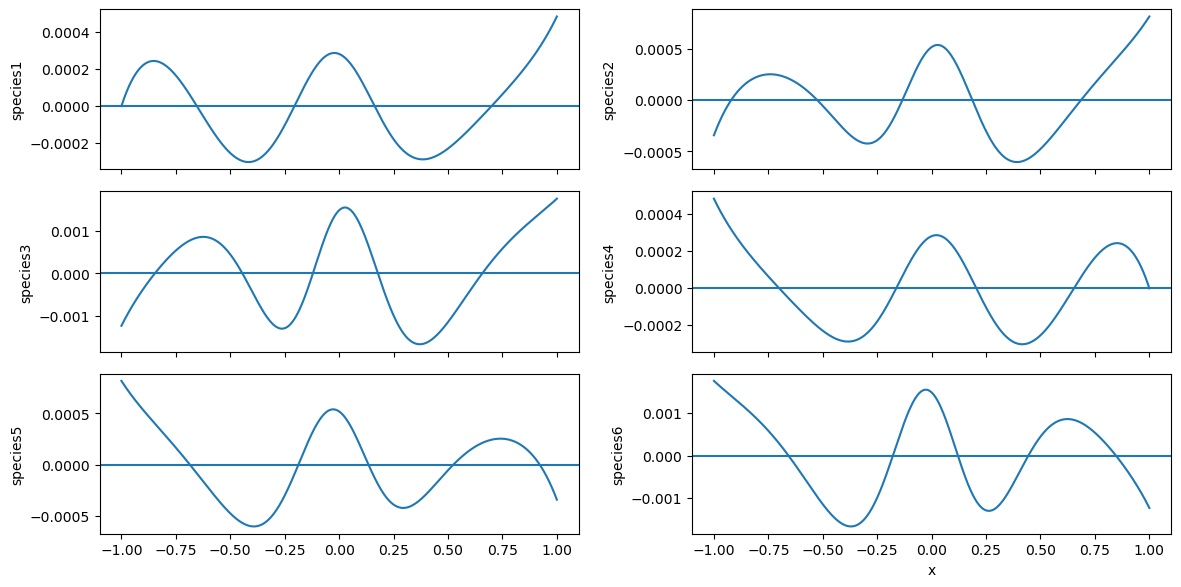

i=0, R² = 0.999984
i=1, R² = 0.999990
i=2, R² = 0.999983
i=3, R² = 0.999984
i=4, R² = 0.999990
i=5, R² = 0.999983


In [59]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def logistic(x, L, k, x0, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def compute_r2(y, y_fit):
    ss_res = np.sum((y - y_fit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return 1 - ss_res / ss_tot

# ===== 画布 =====
fig1, axes1 = plt.subplots(3, 2, figsize=(12, 6), sharex=True)
fig2, axes2 = plt.subplots(3, 2, figsize=(12, 6), sharex=True)

axes1 = axes1.flatten()
axes2 = axes2.flatten()

r2_list = []

# ===== 主循环 =====
for i in range(6):
    y = records[-1][i]

    # 判断趋势（关键！）
    trend = np.mean(np.gradient(y))

    # 拐点估计
    dy = np.gradient(y)
    x0_guess = x[np.argmax(np.abs(dy))]

    # 初始参数（根据趋势）
    if trend > 0:
        k_guess = 1.0   # 正 logistic
    else:
        k_guess = -1.0  # 反 logistic

    p0 = [
        max(y) - min(y),  # L
        k_guess,          # k（关键）
        x0_guess,
        min(y)
    ]

    try:
        params, _ = curve_fit(
            logistic, x, y,
            p0=p0,
            bounds=(
                [0, -10, min(x), -np.inf],
                [np.inf, 10, max(x), np.inf]
            ),
            maxfev=10000
        )
    except RuntimeError:
        print(f"Fit failed for i={i}")
        r2_list.append(np.nan)
        continue

    L, k, x0, b = params

    # 拟合
    y_fit = logistic(x, *params)

    # R²
    r2 = compute_r2(y, y_fit)
    r2_list.append(r2)

    # ===== 图1：拟合 =====
    ax1 = axes1[i]
    ax1.plot(x, y, label='simulation')
    ax1.plot(x, y_fit, '--', label='logistic fit')
    ax1.set_ylabel(f'species{i+1}')
    ax1.set_title(f'R²={r2:.4f}, k={k:.2f}')
    ax1.legend()

    # ===== 图2：残差 =====
    ax2 = axes2[i]
    residual = y - y_fit
    ax2.plot(x, residual)
    ax2.axhline(0)
    ax2.set_ylabel(f'species{i+1}')

# ===== 美化 =====
axes1[-1].set_xlabel('x')
axes2[-1].set_xlabel('x')

#fig1.suptitle('Data vs Logistic Fit')
#fig2.suptitle('Residuals')

plt.tight_layout()
plt.show()

# ===== 输出 R² =====
for i, r2 in enumerate(r2_list):
    print(f'i={i}, R² = {r2:.6f}')

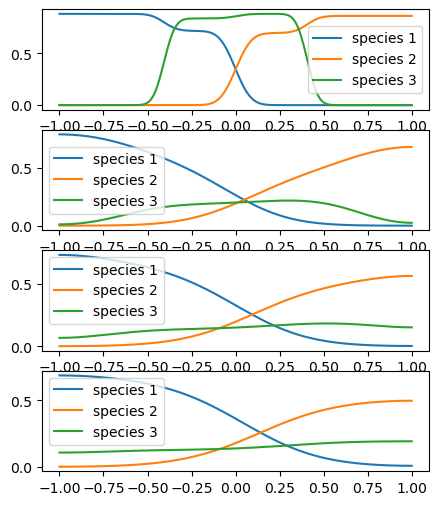

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(5, 6))
axes = axes.flatten()

for i in range(0,4):
    ax = axes[i]
    record = records[1+20*i]
    ax.plot(x, record[0], label='species 1')
    ax.plot(x, record[1], label='species 2')
    ax.plot(x, record[2], label='species 3')
    ax.legend()

plt.show()

C:\Users\muliy\AppData\Local\Temp\ipykernel_13116\2881089017.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


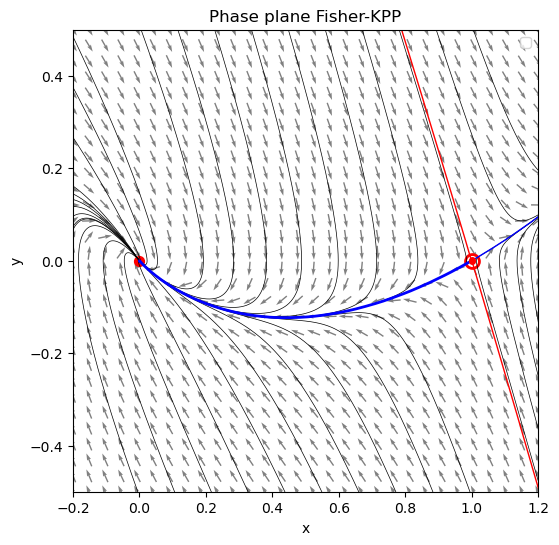

In [114]:
if __name__ == "__main__":
    # 定义微分方程函数
    def Fisher_KPP(t, vars, c):
        u, p = vars
        return np.array([
            p,
            -c*p - u*(1-u)
        ])
    
    # 设置参数

    params = (2,) 
    
    # 初始化绘图器
    plotter = PhasePlotter2D(Fisher_KPP, params=params)
    
    # 创建画布
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in np.linspace(0, 1, 10):
        ax = plotter.plot_solve(ax, [i,0.51], t_end=10, dt=0.01, lw = 0.5)
        ax = plotter.plot_solve(ax, [i,-0.51], t_end=10, dt=0.01, lw = 0.5)
        ax = plotter.plot_solve(ax, [1.21,i-0.5], t_end=10, dt=0.01, lw = 0.5)
        ax = plotter.plot_solve(ax, [-0.21,i-0.5], t_end=10, dt=0.01, lw = 0.5)
    
    ax = plotter.plot_solve(ax, [[1,-0.001]], t_end=100, dt=0.01, color='blue',lw=2)
    ax = plotter.plot_solve(ax, [[1,0.001]], t_end=100, dt=0.01, color='blue',lw = 1)
    ax = plotter.plot_solve(ax, [[1.208,-0.51]], t_end=10, dt=0.01, color='red',lw = 1)
    ax = plotter.plot_solve(ax, [[0.785,0.51]], t_end=10, dt=0.01, color='red',lw = 1)

    plotter.plot_phase_diagram((-0.2, 1.2), (-0.5, 0.5), ax=ax,density=1.5)
    #plotter.plot_nullclines((-0.2, 1.2), (-0.2, 1.2), ax=ax)
    ax.scatter(0, 0, color='red', s=50)
    ax.scatter(1, 0, facecolors='white', edgecolors='red', s=100, linewidths=2)
    
    ax.legend()
    plt.title("Phase plane Fisher-KPP")
    plt.show()

C:\Users\muliy\AppData\Local\Temp\ipykernel_13116\2032100808.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


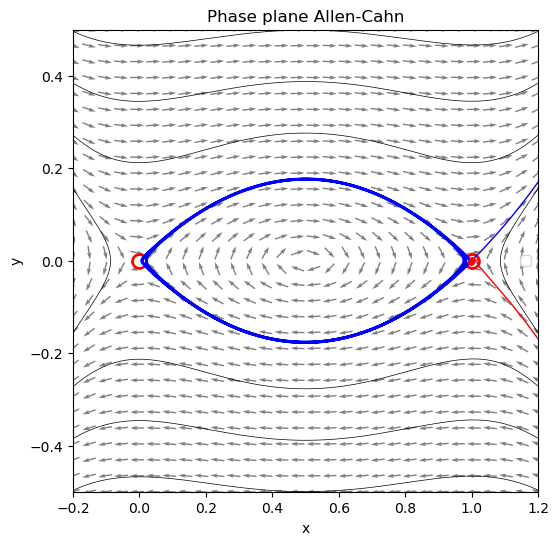

In [193]:
if __name__ == "__main__":
    # 定义微分方程函数
    def Fisher_KPP(t, vars, c):
        u, p = vars
        return np.array([
            p,
            -c*p - u*(1-u)*(u-0.5)
            #-c*p+u**2-u**3
        ])
    
    # 设置参数

    params = (0,) 
    
    # 初始化绘图器
    plotter = PhasePlotter2D(Fisher_KPP, params=params)
    
    # 创建画布
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in np.linspace(0, 1, 10):
        #ax = plotter.plot_solve(ax, [i,0.51], t_end=10, dt=0.01, lw = 0.5)
        #ax = plotter.plot_solve(ax, [i,-0.51], t_end=10, dt=0.01, lw = 0.5)
        ax = plotter.plot_solve(ax, [1.21,i-0.5], t_end=10, dt=0.01, lw = 0.5)
        ax = plotter.plot_solve(ax, [-0.21,i-0.5], t_end=10, dt=0.01, lw = 0.5)
    
    ax = plotter.plot_solve(ax, [[1-0.003,-0.003]], t_end=100, dt=0.01, color='blue',lw=2)
    ax = plotter.plot_solve(ax, [[1,0.001]], t_end=10, dt=0.01, color='blue',lw = 1)
    ax = plotter.plot_solve(ax, [[1.21,-0.179]], t_end=5, dt=0.01, color='red',lw = 1)
    #ax = plotter.plot_solve(ax, [[0.785,0.51]], t_end=10, dt=0.01, color='red',lw = 1)

    plotter.plot_phase_diagram((-0.2, 1.2), (-0.5, 0.5), ax=ax)
    #plotter.plot_nullclines((-0.2, 1.2), (-0.5, 0.5), ax=ax)
    
    #ax.scatter(0.5, 0, color='red', s=50)
    ax.scatter(0, 0, facecolors='white', edgecolors='red', s=100, linewidths=2)
    ax.scatter(1, 0, facecolors='white', edgecolors='red', s=100, linewidths=2)
    
    ax.legend()
    plt.title("Phase plane Allen-Cahn")
    plt.show()

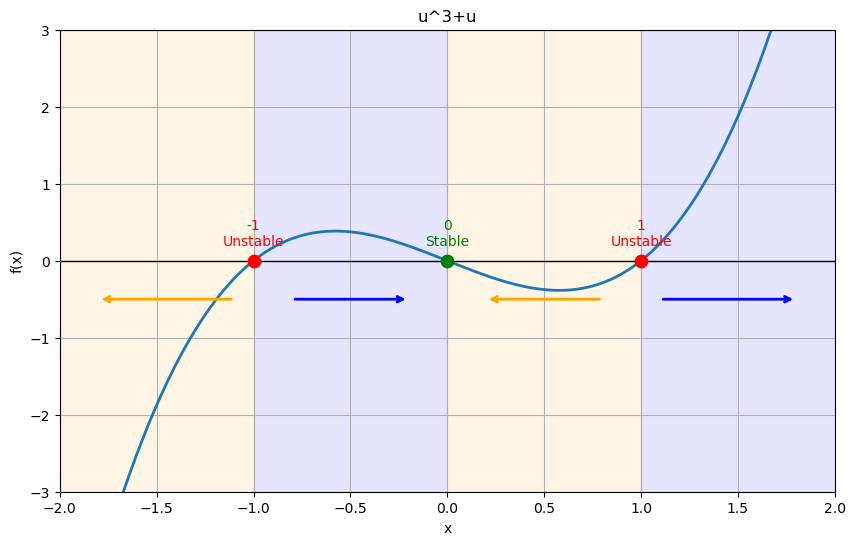

In [4]:
#import numpy as np
#import matplotlib.pyplot as plt

# 定义一维动力系统 dx/dt = f(x)
def f(x):
    return x**3 - x

# 生成 x 范围
x = np.linspace(-2, 2, 500)
y = f(x)

# 找零点（这里直接写出，也可以数值求解）
fixed_points = [-1, 0, 1]

# 判断稳定性
# f'(x) < 0 稳定
# f'(x) > 0 不稳定
def df(x):
    return 3 * x**2 - 1

stability = []
for p in fixed_points:
    if df(p) < 0:
        stability.append("stable")
    else:
        stability.append("unstable")

# 创建图像
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制函数曲线
ax.plot(x, y, label=r'$f(x)=x^3-x$', linewidth=2)
ax.axhline(0, color='black', linewidth=1)

# 标记零点及稳定性
for p, s in zip(fixed_points, stability):
    if s == "stable":
        color = 'green'
        label = 'Stable'
    else:
        color = 'red'
        label = 'Unstable'

    ax.scatter(p, 0, color=color, s=80, zorder=5)
    ax.text(p, 0.2, f'{p}\n{label}', ha='center', color=color)

# 在 x 轴上标出动力系统方向
regions = [(-1.8, -1.1), (-0.8, -0.2), (0.2, 0.8), (1.1, 1.8)]

for a, b in regions:
    mid = (a + b) / 2
    direction = np.sign(f(mid))

    if direction > 0:
        # 向右
        ax.annotate(
            '',
            xy=(b, -0.5),
            xytext=(a, -0.5),
            arrowprops=dict(arrowstyle='->', color='blue', linewidth=2)
        )
    else:
        # 向左
        ax.annotate(
            '',
            xy=(a, -0.5),
            xytext=(b, -0.5),
            arrowprops=dict(arrowstyle='->', color='orange', linewidth=2)
        )

# 给 x 轴动态区域加底色
ax.axvspan(-2, -1, alpha=0.1, color='orange')
ax.axvspan(-1, 0, alpha=0.1, color='blue')
ax.axvspan(0, 1, alpha=0.1, color='orange')
ax.axvspan(1, 2, alpha=0.1, color='blue')

# 设置显示范围
ax.set_xlim(-2, 2)
ax.set_ylim(-3, 3)

# 标签和标题
ax.set_title('u^3+u')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.grid(True)

plt.show()


平衡点:
u = 0.000000, stable
u = 0.500000, unstable
u = 1.000000, stable


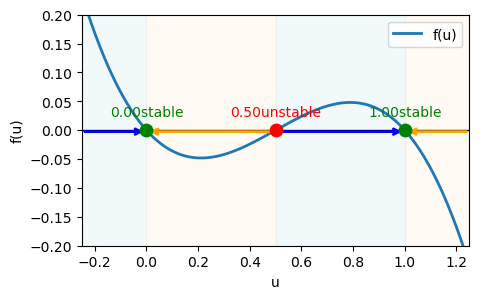

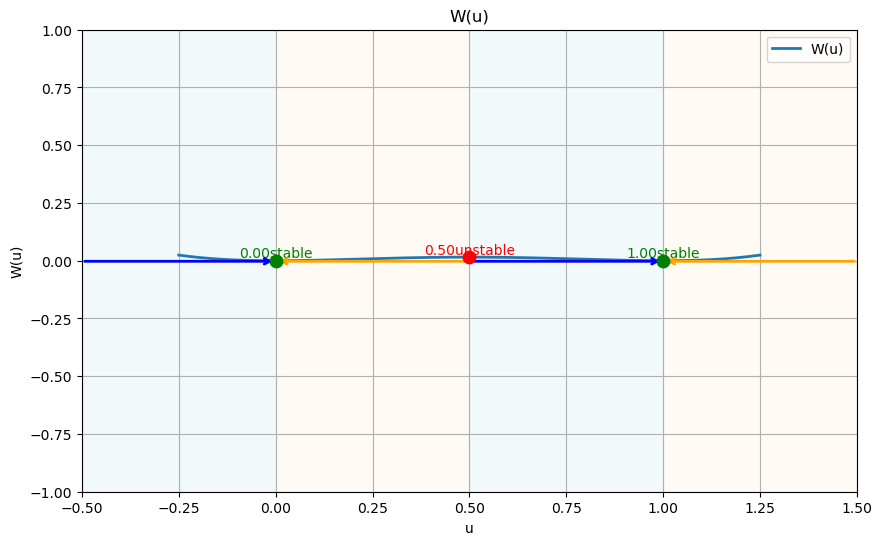

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from scipy.integrate import cumulative_trapezoid


class OneDimensionalDynamicalSystem:
    def __init__(self, f, u_range=(-2, 2), params=None, num_points=1000):
        """
        f: 动力系统函数，形式为 f(u, **params)
        u_range: 绘图范围
        params: 函数参数字典
        """
        self.f = f
        self.params = params if params is not None else {}
        self.u_min, self.u_max = u_range
        self.num_points = num_points

        self.u = np.linspace(self.u_min, self.u_max, self.num_points)
        self.f_values = self.f(self.u, **self.params)

        self.fixed_points = self.find_fixed_points()
        self.stability = self.analyze_stability()
        self.W_values = self.compute_potential()

    def find_fixed_points(self, tol=1e-6):
        """寻找 f(u)=0 的平衡点"""
        fixed_points = []

        for i in range(len(self.u) - 1):
            u1, u2 = self.u[i], self.u[i + 1]
            f1, f2 = self.f_values[i], self.f_values[i + 1]

            # 检查是否跨越零点
            if f1 == 0:
                fixed_points.append(u1)
            elif f1 * f2 < 0:
                try:
                    sol = root_scalar(
                        lambda x: self.f(x, **self.params),
                        bracket=[u1, u2],
                        method='brentq'
                    )
                    fixed_points.append(sol.root)
                except ValueError:
                    pass

        # 去掉重复点
        fixed_points = np.array(fixed_points)
        fixed_points = np.unique(np.round(fixed_points, 6))

        return fixed_points

    def numerical_derivative(self, x, h=1e-5):
        return (
            self.f(x + h, **self.params)
            - self.f(x - h, **self.params)
        ) / (2 * h)

    def analyze_stability(self):
        """通过 f'(u*) 判断稳定性"""
        stability = {}

        for fp in self.fixed_points:
            derivative = self.numerical_derivative(fp)
            if derivative < 0:
                stability[fp] = 'stable'
            elif derivative > 0:
                stability[fp] = 'unstable'
            else:
                stability[fp] = 'neutral'

        return stability

    
    
    def compute_potential(self):
        minus_f = -self.f_values
        W = cumulative_trapezoid(minus_f, self.u, initial=0)
        W0 = np.interp(0, self.u, W)
        W -= W0
        return W

    def plot_phase_line(self, ax, y_position=0, x_range=None):
        """绘制 x 轴上的动力系统流向，并给不同区域添加底色"""
        if x_range is None:
            x_min, x_max = self.u_min, self.u_max
        else:
            x_min, x_max = x_range

        visible_fixed_points = [fp for fp in self.fixed_points if x_min < fp < x_max]
        points = [x_min] + list(visible_fixed_points) + [x_max]

        region_colors = {
            1: 'lightblue',
            -1: 'moccasin'
        }

        for i in range(len(points) - 1):
            left = points[i]
            right = points[i + 1]
            mid = 0.5 * (left + right)

            direction = np.sign(self.f(mid, **self.params))

            # 添加区域底色
            if direction != 0:
                ax.axvspan(
                    left,
                    right,
                    alpha=0.15,
                    color=region_colors.get(direction, 'lightgray')
                )

            # 绘制箭头
            if direction > 0:
                ax.annotate(
                    '',
                    xy=(right, y_position),
                    xytext=(left, y_position),
                    arrowprops=dict(
                        arrowstyle='->',
                        color='blue',
                        linewidth=2
                    )
                )
            elif direction < 0:
                ax.annotate(
                    '',
                    xy=(left, y_position),
                    xytext=(right, y_position),
                    arrowprops=dict(
                        arrowstyle='->',
                        color='orange',
                        linewidth=2
                    )
                )

    def plot_function(self, ax=None, figsize=(5, 3), xlim=None, ylim=None):
        """
        绘制函数图像。
        如果传入 ax，则画在已有坐标轴上；否则自动创建。
        """
        created_fig = False

        if ax is None:
            fig, ax = plt.subplots(figsize=figsize)
            created_fig = True

        ax.plot(self.u, self.f_values, linewidth=2, label='f(u)')
        ax.axhline(0, color='black', linewidth=1)

        for fp in self.fixed_points:
            stability = self.stability[fp]

            if stability == 'stable':
                color = 'green'
            elif stability == 'unstable':
                color = 'red'
            else:
                color = 'gray'

            ax.scatter(fp, 0, color=color, s=80, zorder=5)
            ax.text(
                fp,
                0.05 * (np.max(self.f_values) - np.min(self.f_values)),
                f'{fp:.2f}{stability}',
                ha='center',
                color=color
            )

        y_phase = np.min(self.W_values) - 0.1 * (
            np.max(self.W_values) - np.min(self.W_values)
        )

        phase_x_range = xlim if xlim is not None else (self.u_min, self.u_max)
        self.plot_phase_line(ax, y_position=y_phase, x_range=phase_x_range)

        if xlim is not None:
            ax.set_xlim(xlim)

        if ylim is not None:
            ax.set_ylim(ylim)

        #ax.set_title('f(u)')
        ax.set_xlabel('u')
        ax.set_ylabel('f(u)')
        #ax.grid(True)
        ax.legend()

        if created_fig:
            plt.show()

    def plot_potential(self, ax=None, figsize=(10, 6), xlim=None, ylim=None):
        """
        绘制势能函数图像。
        如果传入 ax，则画在已有坐标轴上；否则自动创建。
        """
        created_fig = False

        if ax is None:
            fig, ax = plt.subplots(figsize=figsize)
            created_fig = True

        ax.plot(self.u, self.W_values, linewidth=2, label='W(u)')

        for fp in self.fixed_points:
            W_fp = np.interp(fp, self.u, self.W_values)
            stability = self.stability[fp]

            if stability == 'stable':
                color = 'green'
            elif stability == 'unstable':
                color = 'red'
            else:
                color = 'gray'

            ax.scatter(fp, W_fp, color=color, s=80, zorder=5)
            ax.text(
                fp,
                W_fp,
                f'{fp:.2f}{stability}',
                ha='center',
                va='bottom',
                color=color
            )

        y_phase = np.min(self.W_values) - 0.1 * (
            np.max(self.W_values) - np.min(self.W_values)
        )

        phase_x_range = xlim if xlim is not None else (self.u_min, self.u_max)
        self.plot_phase_line(ax, y_position=y_phase, x_range=phase_x_range)

        if xlim is not None:
            ax.set_xlim(xlim)

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.set_title('W(u)')
        ax.set_xlabel('u')
        ax.set_ylabel('W(u)')
        ax.grid(True)
        ax.legend()

        if created_fig:
            plt.show()


# =========================
# 使用示例
# =========================


def f(u, a=0.5):
    return u*(1-u)*(u-a)


system = OneDimensionalDynamicalSystem(
    f=f,
    u_range=(-0.25,1.25),
    params={'a': 0.5}
)

print('平衡点:')
for fp in system.fixed_points:
    print(f'u = {fp:.6f}, {system.stability[fp]}')

system.plot_function(xlim=(-0.25,1.25),ylim=(-0.2,0.2))
system.plot_potential(xlim=(-0.5,1.5),ylim=(-1,1))

平衡点:
u = 0.000000, unstable
u = 1.000000, stable


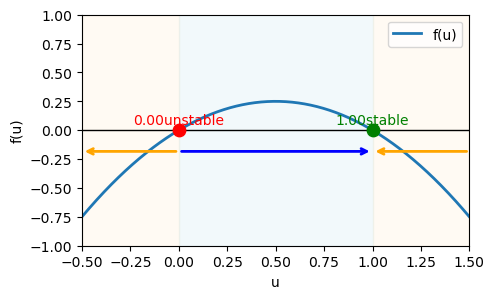

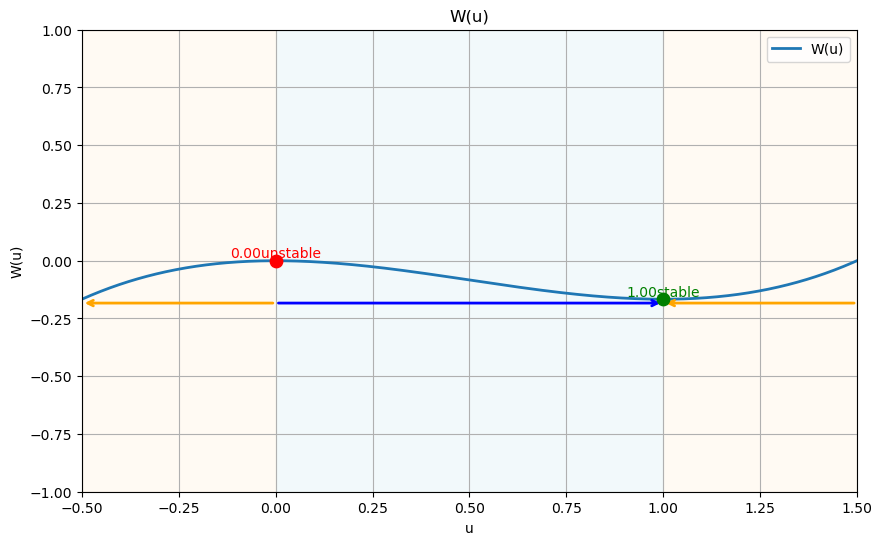

In [6]:
def f(u):
    return u*(1-u)


system = OneDimensionalDynamicalSystem(
    f=f,
    u_range=(-0.5,1.5)
)

print('平衡点:')
for fp in system.fixed_points:
    print(f'u = {fp:.6f}, {system.stability[fp]}')

system.plot_function(xlim=(-0.5,1.5),ylim=(-1,1))
system.plot_potential(xlim=(-0.5,1.5),ylim=(-1,1))

平衡点:
u = -1.000000, stable
u = 0.000000, unstable
u = 1.000000, stable


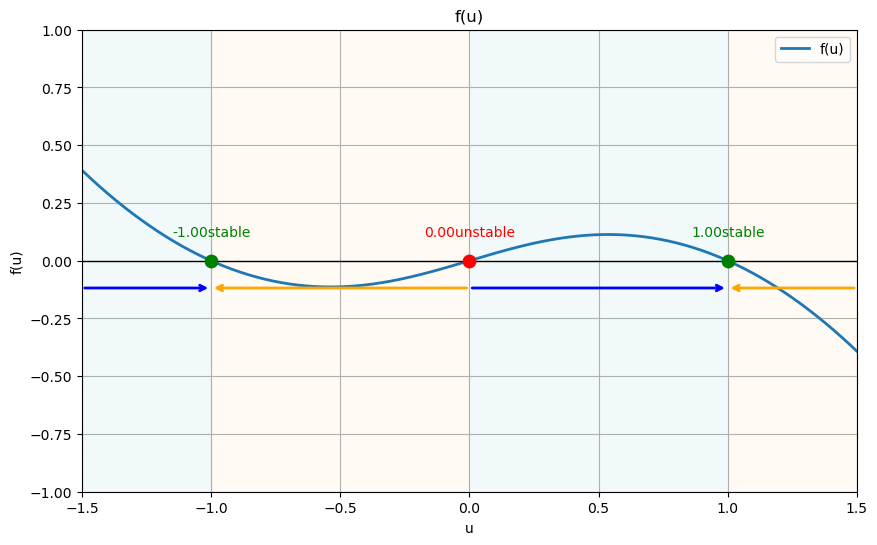

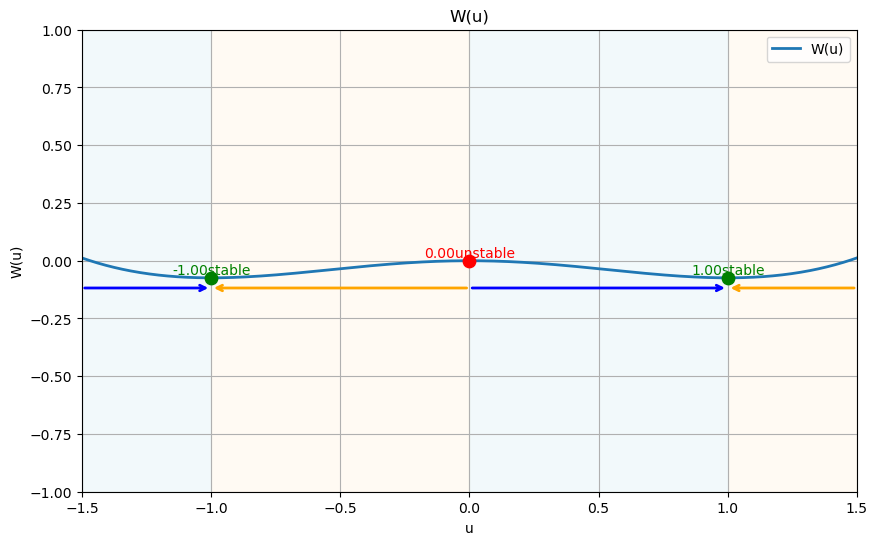

In [37]:
def f(u):
    return u*(1-(1+np.sqrt(1+3*u**2))/3)


system = OneDimensionalDynamicalSystem(
    f=f,
    u_range=(-2, 2)
)

print('平衡点:')
for fp in system.fixed_points:
    print(f'u = {fp:.6f}, {system.stability[fp]}')

system.plot_function(xlim=(-1.5,1.5),ylim=(-1,1))
system.plot_potential(xlim=(-1.5,1.5),ylim=(-1,1))

In [10]:
from sympy import *

In [13]:
x, y, z = symbols('x y z')
y = expand((x + z+ 1)**4) # expand() 是展开函数
y

x**4 + 4*x**3*z + 4*x**3 + 6*x**2*z**2 + 12*x**2*z + 6*x**2 + 4*x*z**3 + 12*x*z**2 + 12*x*z + 4*x + z**4 + 4*z**3 + 6*z**2 + 4*z + 1

In [ ]:

z = Rational(1.5, 2) # 构造分数 1/2
z

3/4

In [24]:
x = symbols('x')
expr = cos(x) + 1
expr.subs(x, 0)
expr

cos(x) + 1

In [26]:
solveset(x*(1-x)*(x-0.5),x)

{0, 0.5, 1}

In [1]:
import numpy as np
from numpy.linalg import inv, eigvals

# =========================
# 参数设置
# =========================
nA = 3                  # 群落A物种数
nB = 3                  # 群落B物种数
max_trials = 10000

# 内部作用范围（弱竞争）
within_low = -0.2
within_high = 0.0

# 跨群落作用范围（强竞争）
between_low = -1.5
between_high = -1.0

# 自限作用
self_regulation = -1.0


def generate_internal_matrix(n):
    """
    生成一个群落内部作用矩阵
    对角线固定为 self_regulation
    非对角线为较弱竞争
    """
    A = np.random.uniform(within_low, within_high, size=(n, n))
    np.fill_diagonal(A, self_regulation)
    return A


def generate_between_matrix(n_from, n_to):
    """
    生成跨群落强竞争矩阵
    """
    return np.random.uniform(between_low, between_high, size=(n_from, n_to))


def equilibrium(A, r):
    """
    求平衡点 x* = -A^{-1} r
    """
    return -inv(A) @ r


def is_locally_stable(A, x_star):
    """
    对于GLV:
        dx_i/dt = x_i(r_i + sum_j A_ij x_j)

    在平衡点处 Jacobian:
        J_ij = x_i^* A_ij
    即 J = diag(x*) @ A
    """
    J = np.diag(x_star) @ A
    eigs = eigvals(J)
    return np.all(np.real(eigs) < 0)


def invasion_growth_rate(invader_indices, resident_indices, A_full, r_full, resident_eq):
    """
    计算入侵物种在居民群落平衡下的线性增长率

    g_i = r_i + sum_j A_ij x_j^resident
    """
    g = []
    for i in invader_indices:
        growth = r_full[i]
        for idx_j, j in enumerate(resident_indices):
            growth += A_full[i, j] * resident_eq[idx_j]
        g.append(growth)
    return np.array(g)


def test_all_subset_invasions(
    invader_indices,
    resident_indices,
    A_full,
    r_full,
    resident_eq
):
    """
    对于“任意组合都无法入侵”，一个保守充分条件是：
    所有单个物种的入侵增长率都为负。
    """
    g = invasion_growth_rate(
        invader_indices,
        resident_indices,
        A_full,
        r_full,
        resident_eq
    )
    return np.all(g < 0)


success = False

for trial in range(max_trials):

    # =========================
    # 生成 r
    # =========================
    rA = np.random.uniform(0.5, 1.5, size=nA)
    rB = np.random.uniform(0.5, 1.5, size=nB)

    # =========================
    # 生成群落内部矩阵
    # =========================
    A_A = generate_internal_matrix(nA)
    A_B = generate_internal_matrix(nB)

    # =========================
    # 检查两个群落各自是否有正平衡且稳定
    # =========================
    try:
        xA = equilibrium(A_A, rA)
        xB = equilibrium(A_B, rB)
    except np.linalg.LinAlgError:
        continue

    if np.any(xA <= 0) or np.any(xB <= 0):
        continue

    if not is_locally_stable(A_A, xA):
        continue

    if not is_locally_stable(A_B, xB):
        continue

    # =========================
    # 生成跨群落强竞争矩阵
    # A_full 的结构:
    #
    # [ A_A   C_AB ]
    # [ C_BA  A_B  ]
    # =========================
    C_AB = generate_between_matrix(nA, nB)
    C_BA = generate_between_matrix(nB, nA)

    A_full = np.block([
        [A_A,   C_AB],
        [C_BA,  A_B]
    ])

    r_full = np.concatenate([rA, rB])

    # 物种索引
    A_indices = np.arange(nA)
    B_indices = np.arange(nA, nA + nB)

    # =========================
    # 检查 B 是否能入侵 A
    # =========================
    B_can_invade_A = test_all_subset_invasions(
        invader_indices=B_indices,
        resident_indices=A_indices,
        A_full=A_full,
        r_full=r_full,
        resident_eq=xA
    )

    # =========================
    # 检查 A 是否能入侵 B
    # =========================
    A_can_invade_B = test_all_subset_invasions(
        invader_indices=A_indices,
        resident_indices=B_indices,
        A_full=A_full,
        r_full=r_full,
        resident_eq=xB
    )

    # 注意：
    # test_all_subset_invasions 返回 True 表示“所有入侵增长率都为负”
    if B_can_invade_A and A_can_invade_B:
        success = True
        break

if success:
    print(f"成功找到满足条件的参数，共尝试 {trial + 1} 次")

    print("\n===== r_full =====")
    print(r_full)

    print("\n===== A_full =====")
    print(A_full)

    print("\n===== 群落A平衡 =====")
    print(xA)

    print("\n===== 群落B平衡 =====")
    print(xB)

    print("\n===== 群落A内部矩阵 A_A =====")
    print(A_A)

    print("\n===== 群落B内部矩阵 A_B =====")
    print(A_B)

    print("\n===== A -> B 跨群落矩阵 C_AB =====")
    print(C_AB)

    print("\n===== B -> A 跨群落矩阵 C_BA =====")
    print(C_BA)

else:
    print("未能在最大尝试次数内找到满足条件的参数，请提高 max_trials")

成功找到满足条件的参数，共尝试 1 次

===== r_full =====
[1.49873781 0.59132728 0.53772138 0.87025378 1.14955028 0.91805128]

===== A_full =====
[[-1.         -0.07751272 -0.0573694  -1.35340404 -1.3697025  -1.36628189]
 [-0.06218772 -1.         -0.05218915 -1.21579904 -1.30391416 -1.06667094]
 [-0.18093572 -0.09643051 -1.         -1.18729994 -1.28205135 -1.0853216 ]
 [-1.23833792 -1.37788664 -1.49730914 -1.         -0.08267935 -0.14589242]
 [-1.40380866 -1.18345969 -1.38938197 -0.16877738 -1.         -0.14126177]
 [-1.06615939 -1.38649361 -1.09146148 -0.18985634 -0.12692295 -1.        ]]

===== 群落A平衡 =====
[1.44769131 0.48936863 0.22859224]

===== 群落B平衡 =====
[0.69539664 0.93796476 0.66697657]

===== 群落A内部矩阵 A_A =====
[[-1.         -0.07751272 -0.0573694 ]
 [-0.06218772 -1.         -0.05218915]
 [-0.18093572 -0.09643051 -1.        ]]

===== 群落B内部矩阵 A_B =====
[[-1.         -0.08267935 -0.14589242]
 [-0.16877738 -1.         -0.14126177]
 [-0.18985634 -0.12692295 -1.        ]]

===== A -> B 跨群落矩阵 C_AB ==

C:\Users\muliy\AppData\Local\Temp\ipykernel_26932\2326667537.py:51: RuntimeWarning: overflow encountered in multiply
  return N * self.r[:, None] * (1 - interaction)
C:\Users\muliy\AppData\Local\Temp\ipykernel_26932\2326667537.py:4: RuntimeWarning: invalid value encountered in subtract
  lap[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
C:\Users\muliy\AppData\Local\Temp\ipykernel_26932\2326667537.py:4: RuntimeWarning: invalid value encountered in add
  lap[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
C:\Users\muliy\AppData\Local\Temp\ipykernel_26932\2326667537.py:4: RuntimeWarning: overflow encountered in divide
  lap[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
C:\Users\muliy\AppData\Local\Temp\ipykernel_26932\2326667537.py:5: RuntimeWarning: invalid value encountered in scalar subtract
  lap[0] = (u[1] - u[0]) / dx**2


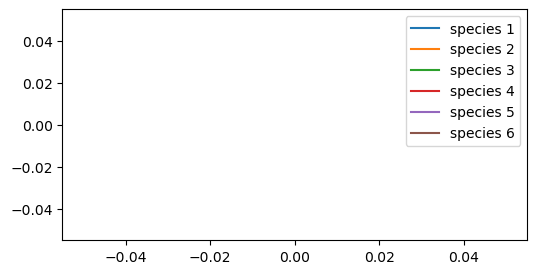

In [24]:
n = 6
D = [0.01, 0.01, 0.01, 0.01, 0.01, 0.01]
r = r_full
A = A_full

model = ReactionDiffusion1D(D, r, A, xspan=(-1, 1), nx=500, dt=5e-4)

x = model.x
N0 = np.zeros((n, len(x)))
N0[:3,:] = xA[:, None]
N0[:3, x>0] = 0
N0[-3:,:] = xB[:, None]
N0[-3:, x<=0] = 0

model.set_initial(N0)

records = model.run(steps=20000, record_interval=500)


fig, ax = plt.subplots(figsize=(6, 3))

t = 2

plt.plot(x, records[t][0], label='species 1')
plt.plot(x, records[t][1], label='species 2')
plt.plot(x, records[t][2], label='species 3')
plt.plot(x, records[t][3], label='species 4')
plt.plot(x, records[t][4], label='species 5')
plt.plot(x, records[t][5], label='species 6')
plt.legend()
plt.show()